# Predict KBO

## KBO 정규 리그 우승팀 및 포스트 시즌 진출 팀 예측

최근 10년간의 정규리그 성적을 바탕으로 2026 시즌 우승팀과 플레이오프 진출팀을 예측하는

머신러닝 모델을 만들어 보자.


### Import Libraries

In [8]:
import pandas as pd
import numpy as np

import matplotlib as mpl
from matplotlib import pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

%matplotlib inline
mpl.rcParams['axes.unicode_minus'] = False

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

### Data Set

Data Source : KBO  Korea Baseball Organization Stat Page

[LINK](https://www.koreabaseball.com/Record/Team/Hitter/Basic1.aspx)


In [10]:
# Read Data 
df = pd.read_csv('data/kbo_data_2025.csv')

In [11]:
# Display first few rows
df.head()

,WIN,POST,YEAR,TEAM,AVG,G,PA,AB,R,H,...,PB,SB_A,CS_A,CS%,SBA,SB,CS,SB%,OOB,PKO_1
0,N,Y,2015,넥센,0.298,144,5811,5069,904,1512,...,10,111,52,31.9,147,100,47,68.0,72,16
1,N,Y,2015,두산,0.290,144,5759,4957,807,1436,...,6,109,48,30.6,158,111,47,70.3,56,6
2,N,N,2015,롯데,0.280,144,5680,4972,765,1393,...,16,107,54,33.5,154,104,50,67.5,56,9
3,Y,Y,2015,삼성,0.302,144,5803,5019,897,1515,...,8,80,49,38.0,209,157,52,75.1,60,6
4,N,N,2015,한화,0.271,144,5716,4852,717,1316,...,14,165,63,27.6,127,80,47,63.0,57,14


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
YEAR,110.0,2020.000000,3.176750,2015.000,2017.00000,2020.0000,2023.000,2025.000
AVG,110.0,0.272827,0.015378,0.237,0.26125,0.2725,0.285,0.309
G,110.0,144.000000,0.000000,144.000,144.00000,144.0000,144.000,144.000
PA,110.0,5654.018182,103.505882,5454.000,5576.25000,5654.0000,5725.750,5870.000
AB,110.0,4959.436364,92.020493,4685.000,4896.00000,4952.5000,5018.000,5176.000
...,...,...,...,...,...,...,...,...
SB,110.0,99.563636,28.915101,47.000,82.25000,98.5000,111.000,204.000
CS,110.0,41.881818,13.666226,11.000,33.25000,41.5000,49.000,101.000
SB%,110.0,70.340909,5.794086,55.800,67.30000,70.2500,74.400,84.700
OOB,110.0,50.290909,8.793602,32.000,44.00000,50.5000,56.000,78.000


In [50]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. 데이터 로드 (사용자의 데이터프레임이 df라고 가정)
# features: 타율, OPS, 득점권타율, 대타타율, 평균자책점, WHIP, 수비율
feature_cols = ['AVG', 'OPS', 'RISP', 'PH-BA', 'ERA', 'WHIP', 'FPCT']
X = df[feature_cols]

# 2. 타겟 데이터 전처리 ("Y"/"N" -> 1/0)
le = LabelEncoder()
y = le.fit_transform(df['POST']) # Y는 1, N은 0으로 변환됨

# 3. 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=27, stratify=y)

# 4. XGBoost 모델 정의
# 시즌 중 데이터임을 고려해 과적합을 방지하는 파라미터 설정을 권장합니다.
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# 5. 모델 학습
model.fit(X_train, y_train)

# 6. 예측 및 성능 평가
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # 진출 확률(0~1)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 0.8182

Classification Report:
              precision    recall  f1-score   support

           N       0.82      0.82      0.82        11
           Y       0.82      0.82      0.82        11

    accuracy                           0.82        22
   macro avg       0.82      0.82      0.82        22
weighted avg       0.82      0.82      0.82        22



<Figure size 1000x600 with 0 Axes>

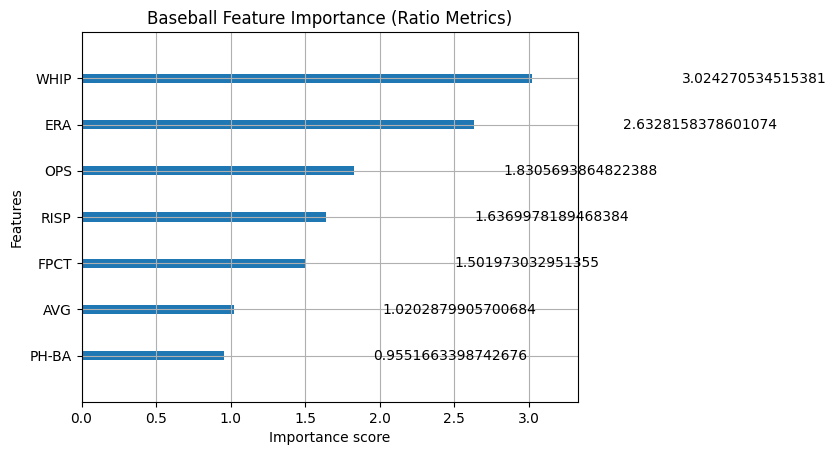

In [51]:
plt.figure(figsize=(10, 6))
xgb.plot_importance(model, importance_type='gain') # 'gain'은 해당 피처가 모델 성능 향상에 기여한 정도
plt.title("Baseball Feature Importance (Ratio Metrics)")
plt.show()